# Predicción de adicción al smartphone — Fase 1

**Proyecto Integrador — Modelos y Simulación de Sistemas I**  
Fuente: Kaggle, *Predicting Smartphone Addiction — Playground Series Season 6 Episode 8*.

## Objetivo
Construir un modelo reproducible de **clasificación binaria** que estime la probabilidad de `addicted_label = 1` a partir de hábitos de uso y características personales. El conjunto de datos utilizado corresponde a la competencia previamente aprobada por el profesor.

> **Alcance:** este notebook prioriza un proceso metodológicamente correcto, reproducible y documentado. Las relaciones encontradas son predictivas dentro de este dataset y no deben interpretarse como causalidad ni como diagnóstico clínico.

## 1. Configuración y carga de datos

El notebook usa rutas relativas para que pueda ejecutarse desde la carpeta `fase-1`. Los archivos esperados son `data/train.csv`, `data/test.csv` y `data/sample_submission.csv`.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
if not (BASE_DIR / "data" / "train.csv").exists() and (BASE_DIR / "fase-1" / "data" / "train.csv").exists():
    BASE_DIR = BASE_DIR / "fase-1"

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "graficos"
OUTPUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
sample_path = DATA_DIR / "sample_submission.csv"

for path in [train_path, test_path, sample_path]:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró {path}. Revisa fase-1/data/README.md")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)
print("Train:", train.shape)
print("Test :", test.shape)
print("Sample submission:", sample_submission.shape)
display(train.head())

Train: (691369, 14)
Test : (296302, 13)
Sample submission: (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 2. Descripción del conjunto de datos

`train.csv` contiene 691.369 observaciones. Hay 12 variables predictoras al excluir el identificador `id` y la variable objetivo `addicted_label`. `test.csv` contiene las mismas variables predictoras y se utiliza para generar probabilidades para Kaggle.

In [2]:
target = "addicted_label"
id_col = "id"
feature_cols = [c for c in train.columns if c not in [id_col, target]]

summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "no_nulos": train.notna().sum(),
    "faltantes": train.isna().sum(),
    "faltantes_pct": (train.isna().mean() * 100).round(3),
    "unicos": train.nunique(dropna=True),
})
display(summary)
print(f"Número de predictores usados: {len(feature_cols)}")

,dtype,no_nulos,faltantes,faltantes_pct,unicos
id,int64,691369,0,0.000,691369
age,float64,662440,28929,4.184,18
daily_screen_time_hours,float64,595515,95854,13.864,1389
social_media_hours,float64,557374,133995,19.381,721
gaming_hours,float64,564548,126821,18.343,401
work_study_hours,float64,639851,51518,7.452,600
sleep_hours,float64,646889,44480,6.434,451
notifications_per_day,float64,623785,67584,9.775,231
app_opens_per_day,float64,610659,80710,11.674,166
weekend_screen_time,float64,579306,112063,16.209,1437


Número de predictores usados: 12


## 3. Análisis exploratorio de datos (EDA)

,conteo,porcentaje
addicted_label,,
0,200895,29.06
1,490474,70.94


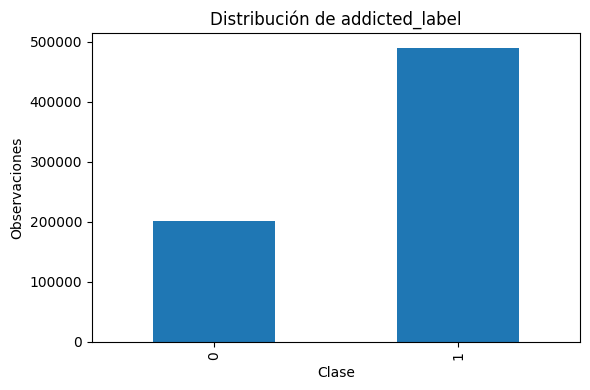

In [3]:
# Balance de la variable objetivo
target_counts = train[target].value_counts().sort_index()
target_pct = (train[target].value_counts(normalize=True).sort_index() * 100).round(2)
target_table = pd.DataFrame({"conteo": target_counts, "porcentaje": target_pct})
display(target_table)

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribución de addicted_label")
ax.set_xlabel("Clase")
ax.set_ylabel("Observaciones")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "distribucion_target.png", dpi=140)
plt.show()

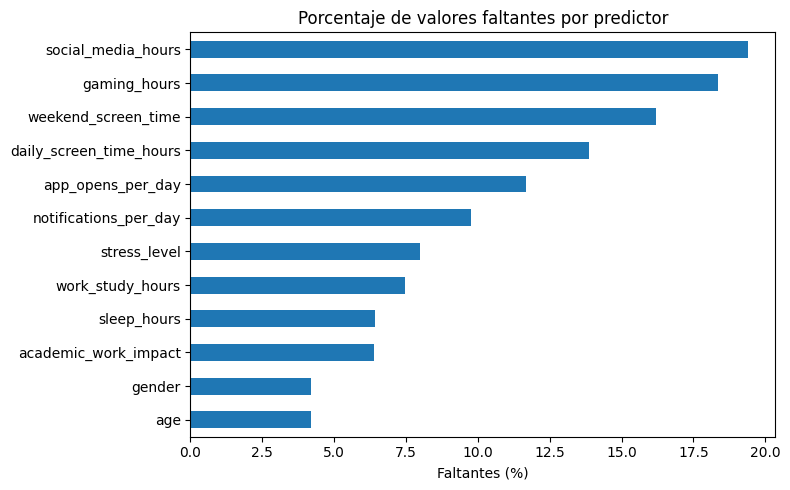

In [4]:
# Valores faltantes
missing_plot = (train[feature_cols].isna().mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
missing_plot.plot(kind="barh", ax=ax)
ax.set_title("Porcentaje de valores faltantes por predictor")
ax.set_xlabel("Faltantes (%)")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "faltantes_por_variable.png", dpi=140)
plt.show()

In [5]:
# Estadísticas descriptivas
numeric_cols = train[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = train[feature_cols].select_dtypes(exclude=np.number).columns.tolist()
print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)
display(train[numeric_cols].describe().T)

for col in categorical_cols:
    print(f"\n{col}")
    display(train[col].value_counts(dropna=False).rename("conteo").to_frame())

Variables numéricas: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Variables categóricas: ['gender', 'stress_level', 'academic_work_impact']


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56



gender


,conteo
gender,
Male,223662
Female,221595
Other,217078
NaN,29034



stress_level


,conteo
stress_level,
High,220873
Low,207783
Medium,207565
NaN,55148



academic_work_impact


,conteo
academic_work_impact,
Yes,330566
No,316579
NaN,44224


### 3.1 Correlaciones numéricas

La correlación se utiliza como herramienta descriptiva. Una correlación alta no implica causalidad y tampoco obliga automáticamente a eliminar variables.

,correlacion_con_target
addicted_label,1.000000
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
age,0.004043
notifications_per_day,-0.011583


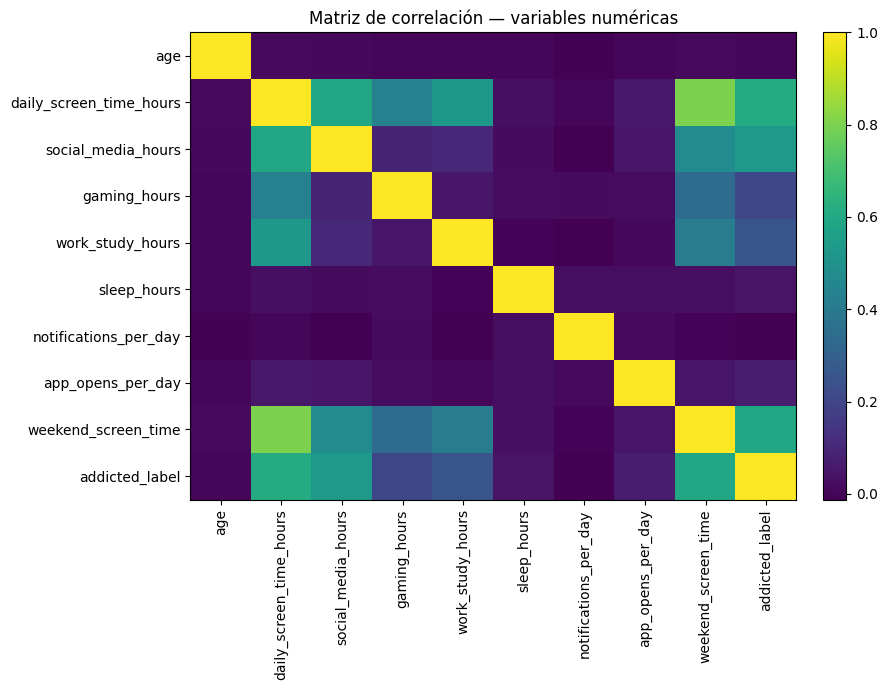

In [6]:
corr_cols = numeric_cols + [target]
corr = train[corr_cols].corr(numeric_only=True)
display(corr[target].sort_values(ascending=False).rename("correlacion_con_target").to_frame())

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)), corr.index)
ax.set_title("Matriz de correlación — variables numéricas")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "matriz_correlacion.png", dpi=140)
plt.show()

### 3.2 Relación descriptiva de predictores con el objetivo

Se comparan promedios por clase para variables numéricas y proporciones de clase positiva para categorías. Esto permite detectar señales predictivas antes del modelado, sin utilizar el conjunto de validación para aprender transformaciones.

In [7]:
numeric_by_target = train.groupby(target)[numeric_cols].mean().T
numeric_by_target.columns = ["media_clase_0", "media_clase_1"]
numeric_by_target["diferencia"] = numeric_by_target["media_clase_1"] - numeric_by_target["media_clase_0"]
display(numeric_by_target.sort_values("diferencia", key=abs, ascending=False))

for col in categorical_cols:
    table = train.assign(**{col: train[col].fillna("Missing")}).groupby(col, dropna=False)[target].agg(["count", "mean"])
    table = table.rename(columns={"mean": "proporcion_clase_1"}).sort_values("proporcion_clase_1", ascending=False)
    print(f"\n{col}")
    display(table)

,media_clase_0,media_clase_1,diferencia
app_opens_per_day,97.871440,104.592844,6.721405
weekend_screen_time,6.848920,10.558729,3.709809
daily_screen_time_hours,5.042929,8.706523,3.663594
notifications_per_day,147.087661,145.406142,-1.681519
social_media_hours,1.376144,2.919495,1.543351
work_study_hours,1.872582,2.569566,0.696984
gaming_hours,1.159677,1.582119,0.422442
sleep_hours,6.722321,6.837970,0.115649
age,26.582864,26.628749,0.045885



gender


,count,proporcion_clase_1
gender,,
Male,223662,0.723198
Missing,29034,0.708790
Female,221595,0.703838
Other,217078,0.701020



stress_level


,count,proporcion_clase_1
stress_level,,
High,220873,0.711431
Low,207783,0.711160
Missing,55148,0.709001
Medium,207565,0.705663



academic_work_impact


,count,proporcion_clase_1
academic_work_impact,,
No,316579,0.711029
Missing,44224,0.709456
Yes,330566,0.707883


## 4. Preparación de datos y prevención de fuga de información

Decisiones:

- `id` se elimina de las variables predictoras porque es un identificador, no una característica del comportamiento.
- La separación se realiza **antes** de aprender imputaciones o codificaciones.
- Se usa una partición 80/20 estratificada para conservar la proporción de clases.
- Numéricas: imputación por mediana. Se agregan indicadores de ausencia, porque el patrón de faltantes puede contener señal predictiva.
- Categóricas: los faltantes se representan con una categoría explícita `Missing` y luego se aplica One-Hot Encoding.
- Las transformaciones se encapsulan dentro de `Pipeline`, evitando ajustar el preprocesamiento sobre validación.

In [8]:
X = train[feature_cols].copy()
y = train[target].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Entrenamiento:", X_train.shape, "Validación:", X_valid.shape)
print("Clase positiva train:", round(y_train.mean(), 4))
print("Clase positiva valid:", round(y_valid.mean(), 4))

Entrenamiento: (553095, 12) Validación: (138274, 12)
Clase positiva train: 0.7094
Clase positiva valid: 0.7094


In [9]:
def make_preprocessor(scale_numeric=False):
    num_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(num_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ])


def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

## 5. Modelo base

El baseline usa la proporción observada de clases (`DummyClassifier(strategy="prior")`). En ROC-AUC, un clasificador sin capacidad discriminativa obtiene aproximadamente 0,5.

In [10]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
dummy_prob = dummy.predict_proba(X_valid)[:, 1]
dummy_metrics = evaluate_probabilities(y_valid, dummy_prob)
display(pd.Series(dummy_metrics, name="DummyClassifier"))

roc_auc          0.500000
accuracy         0.709425
precision        0.709425
recall           1.000000
f1               0.830016
tn               0.000000
fp           40179.000000
fn               0.000000
tp           98095.000000
Name: DummyClassifier, dtype: float64

## 6. Modelo de referencia — Regresión Logística

Se incluye como modelo lineal interpretable y como punto de comparación adicional. Para este modelo se escala la parte numérica.

In [11]:
logistic_pipeline = Pipeline([
    ("preprocess", make_preprocessor(scale_numeric=True)),
    ("model", LogisticRegression(max_iter=300, solver="lbfgs")),
])
logistic_pipeline.fit(X_train, y_train)
logistic_prob = logistic_pipeline.predict_proba(X_valid)[:, 1]
logistic_metrics = evaluate_probabilities(y_valid, logistic_prob)
display(pd.Series(logistic_metrics, name="Regresión Logística"))

roc_auc          0.912258
accuracy         0.840527
precision        0.871962
recall           0.908629
f1               0.889918
tn           27091.000000
fp           13088.000000
fn            8963.000000
tp           89132.000000
Name: Regresión Logística, dtype: float64

## 7. Modelo principal — XGBoost

XGBoost se selecciona por su capacidad para representar relaciones no lineales e interacciones entre variables. El preprocesamiento sigue dentro del pipeline para mantener el aislamiento entre entrenamiento y validación.

In [12]:
xgb_pipeline = Pipeline([
    ("preprocess", make_preprocessor(scale_numeric=False)),
    ("model", XGBClassifier(
        n_estimators=450,
        max_depth=6,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.90,
        min_child_weight=3,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
xgb_pipeline.fit(X_train, y_train)
xgb_prob = xgb_pipeline.predict_proba(X_valid)[:, 1]
xgb_metrics = evaluate_probabilities(y_valid, xgb_prob)
display(pd.Series(xgb_metrics, name="XGBoost"))

roc_auc          0.958843
accuracy         0.894470
precision        0.921320
recall           0.930730
f1               0.926001
tn           32382.000000
fp            7797.000000
fn            6795.000000
tp           91300.000000
Name: XGBoost, dtype: float64

## 8. Comparación de modelos

**ROC-AUC** es la métrica principal porque evalúa la capacidad de ordenar correctamente casos positivos y negativos a través de todos los umbrales. Esto es especialmente útil cuando se generan probabilidades para una competencia. Accuracy, Precision, Recall y F1 se muestran como métricas complementarias a un umbral de 0,5.

In [13]:
results = pd.DataFrame({
    "DummyClassifier": dummy_metrics,
    "Regresión Logística": logistic_metrics,
    "XGBoost": xgb_metrics,
}).T
metric_cols = ["roc_auc", "accuracy", "precision", "recall", "f1"]
display(results[metric_cols].round(4))

metrics_payload = {
    model: {k: (int(v) if k in ["tn", "fp", "fn", "tp"] else float(v)) for k, v in vals.items()}
    for model, vals in {
        "dummy": dummy_metrics,
        "logistic_regression": logistic_metrics,
        "xgboost": xgb_metrics,
    }.items()
}
with open(OUTPUT_DIR / "metricas.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

,roc_auc,accuracy,precision,recall,f1
DummyClassifier,0.5000,0.7094,0.7094,1.0000,0.8300
Regresión Logística,0.9123,0.8405,0.8720,0.9086,0.8899
XGBoost,0.9588,0.8945,0.9213,0.9307,0.9260


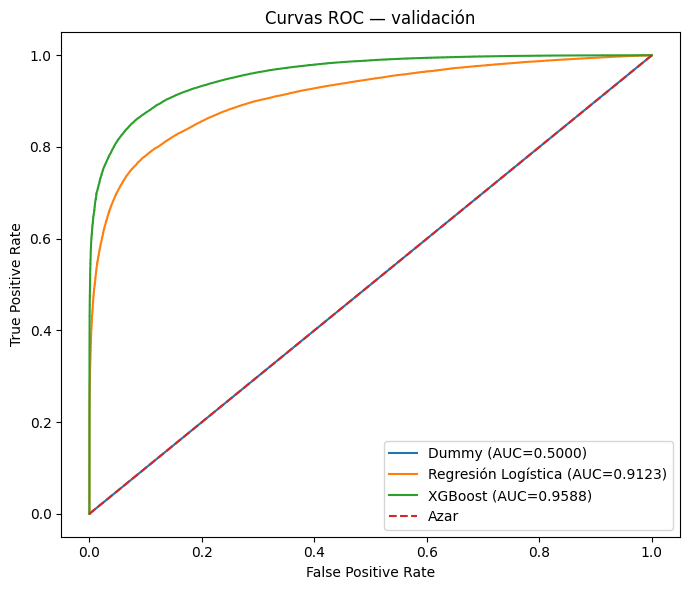

In [14]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob in [
    ("Dummy", dummy_prob),
    ("Regresión Logística", logistic_prob),
    ("XGBoost", xgb_prob),
]:
    fpr, tpr, _ = roc_curve(y_valid, prob)
    auc = roc_auc_score(y_valid, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Azar")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC — validación")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "curvas_roc.png", dpi=140)
plt.show()

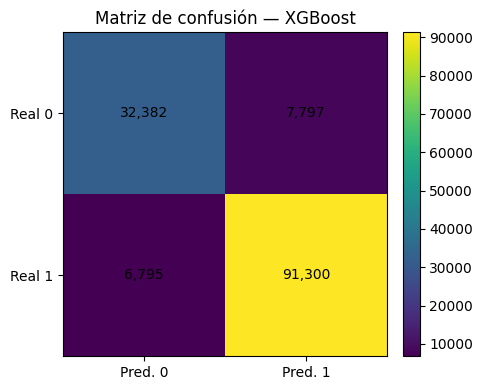

In [15]:
# Matriz de confusión de XGBoost a umbral 0,5
cm = confusion_matrix(y_valid, (xgb_prob >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")
ax.set_xticks([0, 1], ["Pred. 0", "Pred. 1"])
ax.set_yticks([0, 1], ["Real 0", "Real 1"])
ax.set_title("Matriz de confusión — XGBoost")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "matriz_confusion_xgboost.png", dpi=140)
plt.show()

## 9. Importancia de variables

Se muestran las importancias internas del modelo XGBoost sobre las variables transformadas. Estas importancias indican utilidad predictiva para el modelo; **no demuestran causalidad**.

,feature,importance
1,num__daily_screen_time_hours,0.366590
2,num__social_media_hours,0.158489
8,num__weekend_screen_time,0.135416
11,num__missingindicator_social_media_hours,0.046658
6,num__notifications_per_day,0.044631
7,num__app_opens_per_day,0.043272
15,num__missingindicator_notifications_per_day,0.021949
10,num__missingindicator_daily_screen_time_hours,0.021856
17,num__missingindicator_weekend_screen_time,0.021686
4,num__work_study_hours,0.021626


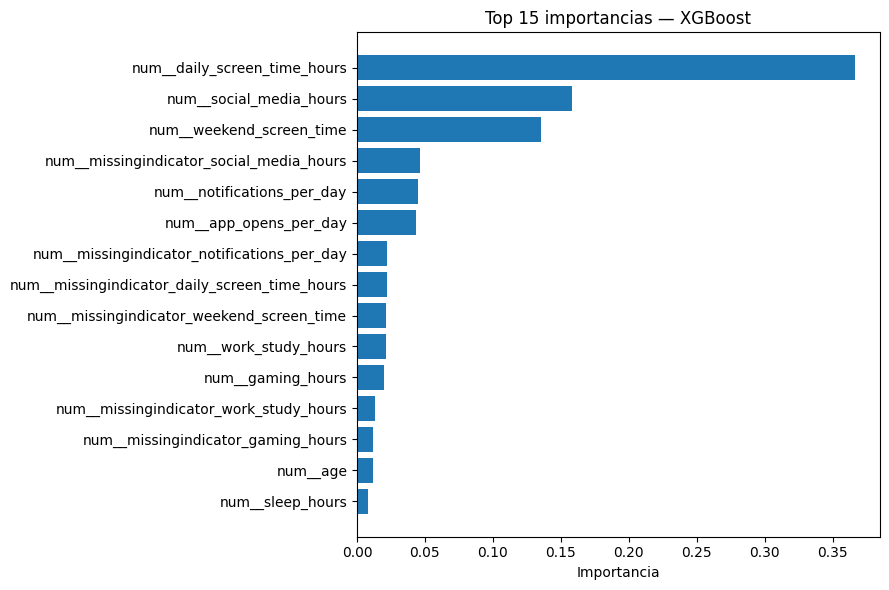

In [16]:
transformed_names = xgb_pipeline.named_steps["preprocess"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": transformed_names,
    "importance": xgb_pipeline.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
display(feature_importance.head(20))

fig, ax = plt.subplots(figsize=(9, 6))
plot_imp = feature_importance.head(15).sort_values("importance")
ax.barh(plot_imp["feature"], plot_imp["importance"])
ax.set_title("Top 15 importancias — XGBoost")
ax.set_xlabel("Importancia")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "importancia_variables.png", dpi=140)
plt.show()

## 10. Entrenamiento final, almacenamiento y predicciones

Después de evaluar los modelos usando una partición no vista, se reentrena el pipeline XGBoost sobre **todo `train.csv`**. Este modelo es el que se almacena para reutilización y se usa para generar `submission.csv`.

In [17]:
final_model = Pipeline([
    ("preprocess", make_preprocessor(scale_numeric=False)),
    ("model", XGBClassifier(
        n_estimators=450,
        max_depth=6,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.90,
        min_child_weight=3,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_model.fit(X, y)

model_path = BASE_DIR / "modelo.joblib"
joblib.dump(final_model, model_path, compress=3)
print("Modelo almacenado en:", model_path)

Modelo almacenado en: /mnt/data/smartphone-addiction-ml/fase-1/modelo.joblib


In [18]:
X_test = test[feature_cols].copy()
test_prob = final_model.predict_proba(X_test)[:, 1]
submission = sample_submission.copy()
submission["addicted_label"] = test_prob

assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission["addicted_label"].between(0, 1).all()

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print("Submission guardado en:", submission_path)
display(submission.head())

# Importancia del modelo final
final_feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
final_importance = pd.DataFrame({
    "feature": final_feature_names,
    "importance": final_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
final_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

Submission guardado en: /mnt/data/smartphone-addiction-ml/fase-1/outputs/submission.csv


,id,addicted_label
0,691369,0.998303
1,691370,0.949338
2,691371,0.960148
3,691372,0.975216
4,691373,0.997202


### 10.1 Prueba de recarga del modelo

La guía exige demostrar que el modelo puede guardarse, cargarse y utilizarse nuevamente para generar predicciones.

In [19]:
loaded_model = joblib.load(model_path)
reloaded_prob = loaded_model.predict_proba(X_test.head(5))[:, 1]
original_prob = final_model.predict_proba(X_test.head(5))[:, 1]
np.testing.assert_allclose(reloaded_prob, original_prob)

reload_check = pd.DataFrame({
    "id": test.loc[:4, "id"].values,
    "probabilidad": reloaded_prob,
})
display(reload_check)
print("Verificación correcta: el modelo recargado reproduce las mismas probabilidades.")

,id,probabilidad
0,691369,0.998303
1,691370,0.949338
2,691371,0.960148
3,691372,0.975216
4,691373,0.997202


Verificación correcta: el modelo recargado reproduce las mismas probabilidades.


## 11. Conclusiones

1. El baseline obtiene ROC-AUC ≈ **0,50**, como se espera de un modelo sin capacidad discriminativa.
2. La Regresión Logística mejora sustancialmente el baseline, con ROC-AUC ≈ **0,9123**.
3. XGBoost alcanza ROC-AUC ≈ **0,9588** en la validación hold-out y es el modelo seleccionado.
4. Las variables relacionadas con tiempo de pantalla muestran señal predictiva importante; sin embargo, la importancia del modelo **no implica causalidad**.
5. El pipeline evita fuga de información al aprender imputaciones y codificaciones únicamente dentro del conjunto de entrenamiento durante la evaluación.
6. El modelo final queda guardado como `modelo.joblib`, se verifica su recarga y se genera `outputs/submission.csv` con probabilidades para `test.csv`.
### Posibles mejoras futuras

- Validación cruzada estratificada para estimar con mayor robustez la variabilidad del desempeño.
- Ajuste sistemático de hiperparámetros con presupuesto computacional controlado.
- Calibración de probabilidades si una fase posterior requiere interpretar la probabilidad como riesgo absoluto.
- Análisis de estabilidad por subgrupos y monitoreo de drift en fases de despliegue.